100%|██████████| 9.91M/9.91M [00:00<00:00, 129MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 49.5MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 56.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.57MB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_780/3160530746.py:263: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


EP1 loss=0.139 test_acc=0.945
EP2 loss=0.161 test_acc=0.974
EP3 loss=0.094 test_acc=0.980
EP4 loss=0.003 test_acc=0.985
EP5 loss=0.009 test_acc=0.985


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


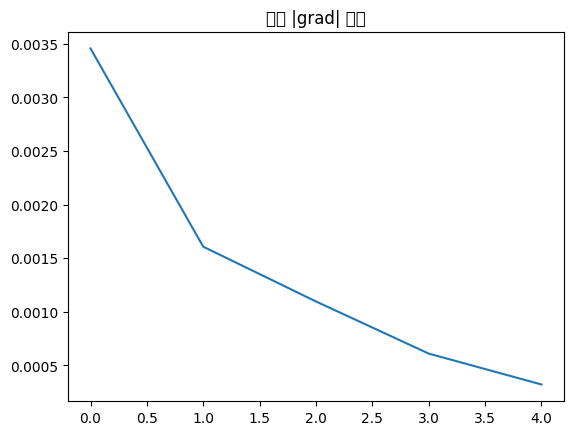

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/us

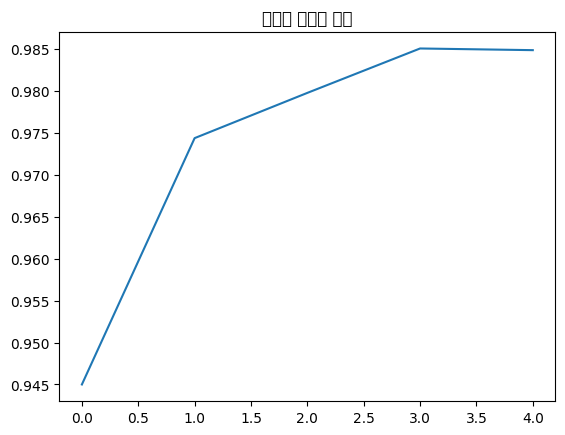

In [ ]:
# Batch Normalization은 한 층의 출력값이 배치마다 너무 들쭉날쭉해지지 않도록, 미니배치 기준 평균과 분산으로 정규화한 뒤 다시 학습 가능한 스케일과 이동을 적용하는 기법입니다.
# 쉽게 말해, 각 층으로 들어가는 값의 스케일을 너무 크지도 너무 작지도 않게 맞춰서 학습을 더 안정적으로 만들려는 장치입니다.

# 딥러닝에서는 층이 깊어질수록 각 층에 들어가는 값의 분포가 계속 흔들릴 수 있는데, BatchNorm은 각 배치의 평균과 분산을 이용해 그 분포를 정리해 줍니다.
# 보통은 선형층이나 합성곱층 뒤에 두고, 활성화 함수 앞이나 근처에 배치하는 식으로 사용합니다.
# 개념적으로는 먼저 배치 평균과 분산으로 정규화하고, 그다음 학습 가능한 γ와 β로 다시 크기와 위치를 조정합니다.
# 예를 들어 한 반 학생들 키가 매번 제각각이라면 비교가 어렵지만, 매번 평균과 퍼짐을 맞춰 놓으면 다음 단계에서 훨씬 다루기 쉬운 것과 비슷합니다.
# 즉 BatchNorm은 “값을 완전히 바꿔버리는 것”이 아니라, 모델이 다루기 쉬운 범위로 정리해 주는 보조 장치에 가깝습니다.

# 왜 쓰는가
# BatchNorm을 쓰는 가장 큰 이유는 학습을 더 빠르고 안정적으로 만들기 위해서입니다.
# 이 기법을 쓰면 더 큰 학습률을 써도 비교적 안정적인 경우가 많고, 초기화에 덜 민감해지는 경향이 있습니다.
# 또한 층별 gradient 크기 차이가 너무 커지는 현상을 완화해, 깊은 네트워크에서 학습이 잘 되도록 돕는 경우가 많습니다.
# 추가로 BatchNorm은 미니배치 통계를 사용하므로 약간의 regularization 효과를 줄 수 있어, 경우에 따라 과적합 완화에도 도움이 될 수 있습니다.
# 다만 배치 크기가 너무 작으면 배치 평균과 분산이 불안정해져 성능이 흔들릴 수 있습니다.

# Layer Normalization은 BatchNorm과 비슷하게 값을 정리해 학습을 안정화하는 기법이지만, 평균과 분산을 배치 축이 아니라 한 샘플 내부의 feature 축에서 계산합니다.
# 즉 BatchNorm이 “배치 안에서 같은 feature끼리” 통계를 본다면, LayerNorm은 “샘플 하나 안의 모든 feature들”을 기준으로 정규화합니다.
# 그래서 LayerNorm은 배치 크기에 덜 의존하고, 작은 배치나 순차 데이터 모델에서도 안정적으로 동작합니다.
# 특히 RNN이나 Transformer처럼 시퀀스 데이터를 다루는 구조에서 LayerNorm이 자주 사용됩니다.
# Transformer에서 LayerNorm이 중요한 이유도, 배치 크기에 크게 의존하지 않으면서 각 토큰 표현을 안정적으로 정규화해 주기 때문입니다.

# 차이와 감각
# BatchNorm은 “여러 샘플을 모아 놓은 배치 전체를 보고 정규화”하는 방식이고, LayerNorm은 “샘플 하나를 따로 놓고 그 안에서 정규화”하는 방식입니다.
# 그래서 CNN처럼 배치를 충분히 크게 잡기 쉬운 환경에서는 BatchNorm이 많이 쓰이고, 배치 크기가 작거나 길이가 가변적인 시퀀스 모델에서는 LayerNorm이 더 자연스러운 경우가 많습니다.
# 아주 직관적으로 말하면, BatchNorm은 “반 전체 평균에 맞춰 조정”하는 방식이고, LayerNorm은 “학생 한 명 안의 과목 점수 분포를 정리”하는 방식에 가깝습니다.
# 둘 다 목적은 비슷하게 학습을 안정화하고 수렴을 돕는 것이지만, 어디 기준으로 평균과 분산을 구하느냐가 가장 큰 차이입니다.


# 5차시 보강 실습: Grad 분포 & Scheduler (Colab 호환)

# torch                : 파이토치 본체임
# nn                   : 신경망 레이어/손실함수 등을 담은 모듈임
# optim                : 옵티마이저(SGD, AdamW 등)를 담은 모듈임
import torch, torch.nn as nn, torch.optim as optim

# datasets             : MNIST 같은 공개 데이터셋을 쉽게 불러오기 위함
# transforms           : 이미지를 텐서로 바꾸는 전처리 도구임
from torchvision import datasets, transforms

# DataLoader           : 데이터셋을 배치 단위로 잘라서 학습 루프에 넣어주는 도구임
from torch.utils.data import DataLoader

# matplotlib           : 학습 결과(grad 추세, 정확도 추세)를 그래프로 그리기 위함
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. 연산 장치 선택
# ------------------------------------------------------------
# cuda 사용 가능하면 GPU로 학습하고,
# 아니면 CPU로 학습하겠다는 뜻임
# 딥러닝은 GPU가 훨씬 빠른 경우가 많아서 보통 이렇게 먼저 장치 선택함
device = 'cuda' if torch.cuda.is_available() else 'cpu'


# ------------------------------------------------------------
# 2. 데이터 전처리 정의
# ------------------------------------------------------------
# transforms.Compose([...]) : 여러 전처리를 순서대로 묶는 컨테이너임
# 여기서는 transforms.ToTensor() 하나만 사용 중임
#
# ToTensor()가 하는 일
# - PIL 이미지나 numpy 이미지를 torch.Tensor로 바꿔줌
# - 보통 픽셀값 0~255 정수를 0~1 범위의 float 텐서로 바꿔줌
#
# 즉 이 코드에선 "복잡한 전처리 없이, 이미지 → 텐서"만 하고 있음
tfm = transforms.Compose([transforms.ToTensor()])


# ------------------------------------------------------------
# 3. MNIST 데이터셋 다운로드 및 로딩
# ------------------------------------------------------------
# root='/tmp/mnist'
# - MNIST 파일을 저장할 경로임
# - Colab에서는 임시 경로에 저장해도 실습엔 충분함
#
# train=True
# - 학습용 데이터셋을 불러오겠다는 뜻임
#
# train=False
# - 테스트용 데이터셋을 불러오겠다는 뜻임
#
# download=True
# - 해당 경로에 데이터가 없으면 자동 다운로드함
#
# transform=tfm
# - 위에서 만든 전처리(ToTensor)를 각 이미지에 적용함
train_ds = datasets.MNIST(root='/tmp/mnist', train=True, download=True, transform=tfm)
test_ds  = datasets.MNIST(root='/tmp/mnist', train=False, download=True, transform=tfm)


# ------------------------------------------------------------
# 4. DataLoader 생성
# ------------------------------------------------------------
# DataLoader는 데이터셋을 "미니배치" 단위로 나눠서 꺼내줌
#
# train_loader
# - batch_size=256 : 학습할 때 한 번에 이미지 256장을 넣겠다는 뜻임
# - shuffle=True   : 학습 데이터는 매 epoch마다 섞는 게 일반적임
#                    그래야 특정 순서에 모델이 치우치지 않음
# - num_workers=2  : 데이터를 미리 읽어오는 subprocess 개수임
#                    Colab 환경에서 적당한 값으로 자주 씀
# - pin_memory=True: GPU 사용 시 CPU→GPU 메모리 복사를 조금 더 빠르게 도와줄 수 있음
#
# test_loader
# - batch_size=512 : 테스트는 역전파 안 하므로 더 큰 배치도 자주 사용함
# - shuffle=False  : 테스트는 순서를 섞을 필요가 거의 없음
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2, pin_memory=True)


# ------------------------------------------------------------
# 5. 모델 정의
# ------------------------------------------------------------
# nn.Module을 상속받아 MLP(다층 퍼셉트론) 모델 정의함
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        # self.f 안에 레이어를 순서대로 쌓아둠
        # nn.Sequential을 쓰면 forward에서 한 줄로 통과시킬 수 있어 편함
        self.f = nn.Sequential(

            # 입력 이미지는 보통 [배치크기, 1, 28, 28] 형태임
            # Flatten은 이를 [배치크기, 784]로 펴줌
            # 즉 28x28 이미지를 일렬로 펼쳐서 완전연결층에 넣는 준비 단계임
            nn.Flatten(),

            # 첫 번째 선형층
            # 입력 784개 픽셀 → 은닉노드 512개로 보냄
            nn.Linear(28*28, 512),

            # 비선형성 추가
            # 선형층만 여러 개 쌓으면 결국 하나의 선형변환과 다를 게 적어서
            # 중간에 ReLU 같은 활성화함수가 꼭 필요함
            nn.ReLU(),

            # 두 번째 선형층
            # 512 → 256으로 차원 줄임
            nn.Linear(512, 256),
            nn.ReLU(),

            # 마지막 출력층
            # MNIST 숫자 0~9, 총 10개 클래스 점수(logit)를 출력함
            nn.Linear(256, 10)
        )

        # He 초기화 (ReLU에 적합)
        # 각 Linear 레이어의 weight를 kaiming_normal_로 초기화함
        # ReLU를 쓸 때 신호 크기와 gradient 흐름을 비교적 안정적으로 유지하는 데 자주 사용함
        # bias는 0으로 초기화함
        for m in self.f:
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    # forward는 "입력 x가 들어왔을 때 출력이 어떻게 계산되는가"를 정의하는 함수임
    # 여기서는 Sequential 전체를 그대로 통과시키면 끝임
    def forward(self, x):
        return self.f(x)


# ------------------------------------------------------------
# 6. 모델 / 옵티마이저 / 스케줄러 / 손실함수 생성
# ------------------------------------------------------------

# 모델을 생성한 뒤 device(CPU or GPU)로 보냄
model = MLP().to(device)

# AdamW 옵티마이저 사용함
# model.parameters() : 학습할 파라미터(weight, bias)들을 넘겨줌
# lr=3e-3            : 초기 학습률(learning rate)임
#
# AdamW는 Adam 계열이면서 weight decay를 조금 더 명확하게 처리하는 방식임
# 보통 안정적으로 잘 학습되는 편이라 실습에서 자주 사용함
opt = optim.AdamW(model.parameters(), lr=3e-3)

# OneCycleLR 스케줄러 생성
# 학습률을 epoch 전체 동안 고정하지 않고,
# 초반엔 올리고, 후반엔 내리는 식으로 자동 조절함
#
# max_lr=3e-3
# - 사이클 중 최고 learning rate임
#
# steps_per_epoch=len(train_loader)
# - 한 epoch에 몇 번 optimizer step을 하는지 알려줌
# - 보통 "미니배치 개수"와 같음
#
# epochs=5
# - 총 5 epoch 학습 기준으로 스케줄을 설계함
#
# 즉 sched.step()이 배치마다 호출되면서,
# learning rate가 훈련 중 동적으로 바뀜
sched = optim.lr_scheduler.OneCycleLR(
    opt,
    max_lr=3e-3,
    steps_per_epoch=len(train_loader),
    epochs=5
)

# 분류 문제 손실함수
# CrossEntropyLoss는 다중 클래스 분류에서 가장 자주 쓰는 손실함수 중 하나임
# 모델 출력은 보통 softmax 전의 logit이어야 하고,
# 정답 y는 클래스 인덱스(0~9) 형태면 됨
crit = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# 7. Gradient 기록용 리스트 및 hook 함수 정의
# ------------------------------------------------------------

# grads 리스트
# - 각 backward 시점에 gradient 크기를 기록하려는 용도임
# - 여기서는 "절댓값 평균"을 저장하고 있음
grads = []

def hook_fn(m, gi, go):
    # m  : hook이 걸린 모듈 자체임
    # gi : grad_input, 모듈 입력 쪽 gradient 정보임
    # go : grad_output, 모듈 출력 쪽 gradient 정보임
    #
    # 여기서는 gi, go를 직접 쓰진 않고,
    # "지금 backward가 특정 Linear 레이어를 지나가는 순간"을 포착하려는 용도로 hook 사용 중임

    if isinstance(m, nn.Linear):
        # m.weight.grad가 존재하면
        # 현재 레이어 weight gradient의 절댓값 평균을 grads에 기록함
        #
        # detach() : 계산 그래프와 연결 끊기 위함
        # abs()    : 부호는 버리고 크기만 보기 위함
        # mean()   : 전체 weight gradient를 하나의 대표 숫자로 압축함
        # item()   : 0차원 텐서를 파이썬 숫자로 변환함
        if m.weight.grad is not None:
            grads.append(m.weight.grad.detach().abs().mean().item())


# ------------------------------------------------------------
# 8. 각 Linear 레이어에 backward hook 등록
# ------------------------------------------------------------
# model.modules()는 모델 내부의 모든 하위 모듈을 순회함
# 그 중 nn.Linear인 레이어들만 골라서 backward hook을 등록함
#
# register_full_backward_hook(...)
# - 해당 모듈에서 backward가 일어날 때 hook_fn을 호출하도록 연결함
#
# hooks 리스트에 핸들을 저장하는 이유
# - 나중에 h.remove()로 hook 해제하려고 저장해두는 것임
hooks = [
    m.register_full_backward_hook(hook_fn)
    for m in model.modules()
    if isinstance(m, nn.Linear)
]


# ------------------------------------------------------------
# 9. 한 epoch 학습 함수
# ------------------------------------------------------------
def train_epoch():
    # model.train()
    # - 학습 모드로 전환함
    # - Dropout, BatchNorm 같은 레이어가 있다면 동작 방식이 달라짐
    # - 이 모델엔 해당 레이어가 없지만, 습관적으로 train/eval을 명확히 나누는 게 좋음
    model.train()

    # tot     : 총 샘플 수 누적용
    # correct : 정답 개수 누적용
    tot = 0
    correct = 0

    # train_loader에서 미니배치 단위로 데이터 꺼냄
    for x, y in train_loader:

        # x, y를 현재 연산 장치(device)로 이동함
        # GPU를 쓴다면 GPU 메모리로 옮겨야 실제 GPU 계산이 가능함
        x, y = x.to(device), y.to(device)

        # 이전 배치에서 계산된 gradient를 초기화함
        # 파이토치는 기본적으로 gradient를 누적(accumulate)하므로,
        # 배치마다 zero_grad()를 해주는 게 일반적임
        opt.zero_grad()

        # 순전파(forward)
        # x를 모델에 넣어 예측 점수(logit)를 얻음
        out = model(x)

        # 예측값 out과 정답 y를 비교하여 손실 계산함
        loss = crit(out, y)

        # 역전파(backward)
        # loss를 기준으로 모든 파라미터의 gradient 계산함
        loss.backward()

        # optimizer.step()
        # 방금 계산된 gradient를 이용해 파라미터 업데이트함
        opt.step()

        # scheduler.step()
        # 현재 스텝이 끝났으니 learning rate 스케줄도 한 칸 진행함
        # OneCycleLR은 보통 배치마다 step() 호출함
        sched.step()

        # 현재 배치 샘플 수 누적
        tot += y.size(0)

        # out.argmax(1)
        # - 클래스 차원(dim=1)에서 가장 큰 logit의 인덱스를 선택함
        # - 즉 예측 클래스 번호를 의미함
        #
        # (out.argmax(1) == y)
        # - 예측 클래스와 실제 정답이 같은지 비교한 bool 텐서임
        #
        # .sum().item()
        # - 맞춘 개수를 숫자로 더함
        correct += (out.argmax(1) == y).sum().item()

    # 여기서 return하는 loss는 "마지막 배치 loss"임
    # epoch 평균 loss는 아님
    # 정확도는 전체 배치를 누적했으므로 epoch 전체 train accuracy임
    return loss.item(), correct / tot


# ------------------------------------------------------------
# 10. 평가 함수
# ------------------------------------------------------------
def eval_epoch():
    # model.eval()
    # - 평가 모드로 전환함
    # - Dropout, BatchNorm 등이 있으면 학습 모드와 다르게 동작함
    model.eval()

    tot = 0
    correct = 0

    # 평가 시엔 gradient 계산이 필요 없음
    # 따라서 torch.no_grad()를 써서 메모리 절약 + 속도 향상함
    with torch.no_grad():
        for x, y in test_loader:
            x, y = x.to(device), y.to(device)

            # 순전파만 수행함
            out = model(x)

            # 샘플 수 누적
            tot += y.size(0)

            # 예측 정확도 누적
            correct += (out.argmax(1) == y).sum().item()

    # 테스트 정확도 반환
    return correct / tot


# ------------------------------------------------------------
# 11. 기록용 리스트
# ------------------------------------------------------------
# hist_grad : epoch별 평균 gradient 크기 추세 기록용
# hist_acc  : epoch별 테스트 정확도 기록용
hist_grad = []
hist_acc  = []


# ------------------------------------------------------------
# 12. 실제 학습 루프
# ------------------------------------------------------------
for ep in range(5):
    # 한 epoch 학습
    loss, tr_acc = train_epoch()

    # 한 epoch 끝난 뒤 테스트셋 평가
    acc = eval_epoch()

    # grads 리스트에는 backward hook이 기록한 gradient 값들이 계속 쌓임
    #
    # 여기서 의도는
    # "이번 epoch에서 기록된 gradient들만 평균내서 hist_grad에 넣자"에 가까움
    #
    # grads[-len(train_loader):]
    # - grads의 맨 뒤에서 "배치 수만큼"만 가져오겠다는 뜻임
    #
    # 다만 주의점이 있음
    # - 현재 hook은 Linear 레이어마다 기록될 수 있어서,
    #   실제로는 '배치 수'와 기록 수가 정확히 1:1이 아닐 수 있음
    # - 즉 이 값은 대략적인 gradient 크기 추세를 보는 용도 정도로 이해하는 게 좋음
    #
    # max(1, len(train_loader))
    # - 혹시 0으로 나누는 상황을 피하려는 안전장치 느낌임
    hist_grad.append(sum(grads[-len(train_loader):]) / max(1, len(train_loader)))

    # 테스트 정확도 기록
    hist_acc.append(acc)

    # epoch 결과 출력
    # loss는 마지막 배치의 손실
    # acc는 전체 테스트 정확도
    print(f"EP{ep+1} loss={loss:.3f} test_acc={acc:.3f}")


# ------------------------------------------------------------
# 13. 시각화
# ------------------------------------------------------------

# epoch별 평균 |grad| 추세 시각화
# gradient 절댓값 평균이 epoch에 따라 어떻게 변하는지 대략 확인하는 그래프임
#
# 해석 예시
# - 너무 작아져서 거의 0에 가까우면 gradient vanishing 경향을 의심할 수 있음
# - 너무 커지면 gradient explosion이나 학습 불안정 가능성을 의심할 수 있음
# - 완만히 줄어들며 안정적이면 학습이 어느 정도 잘 진행 중일 수 있음
plt.figure()
plt.plot(hist_grad)
plt.title('평균 |grad| 추세')
plt.show()

# epoch별 테스트 정확도 추세 시각화
# 학습이 진행되면서 일반화 성능이 좋아지는지 확인하는 용도임
plt.figure()
plt.plot(hist_acc)
plt.title('테스트 정확도 추세')
plt.show()


# ------------------------------------------------------------
# 14. hook 해제
# ------------------------------------------------------------
# register_full_backward_hook로 걸어둔 hook은
# 실험이 끝나면 remove()로 정리해주는 게 좋음
# 안 그러면 이후 다른 실험에서 의도치 않게 hook이 계속 동작할 수 있음
for h in hooks:
    h.remove()